# Audio Captioning: Systematic Ablation Study

**Pipeline:** CLAP audio encoder (frozen) -> MLP projection -> Language Model  
**Dataset:** MusicCaps (~4,500 train / ~500 val / ~550 test)  
**Baseline:** 2-layer MLP, prefix_len=8, dropout=0.3, greedy decoding, LRs tuned per model (Optuna, 16 trials)  
**Noise floor:** 3 seeds per model (42, 43, 44) -- deltas below 1 std are not interpreted as effects

| Model | Type | Params | S1 Epochs | Batch |
|-------|------|--------|-----------|-------|
| GPT-2 | Decoder-only | 124M | 30 | 8 |
| T5-base | Encoder-decoder | 220M | 50 | 8 |

In [ ]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "figure.facecolor": "white",
})

RESULTS_DIR = Path("../results")
MODELS = ["gpt2", "t5"]
METRICS = ["BLEU-1", "BLEU-4", "METEOR", "ROUGE-L", "CIDEr-D", "SPICE", "SPIDEr", "FENSE"]
PRIMARY = "FENSE"

In [ ]:
def load_json(path):
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None


def collect_eval_results(ablation_type="arch"):
    rows = []
    for model in MODELS:
        ablation_dir = RESULTS_DIR / model / "ablations" / ablation_type
        if not ablation_dir.exists():
            continue
        for f in sorted(ablation_dir.glob(f"{model}_ablation_*.json")):
            d = load_json(f)
            if d is None:
                continue
            tag = f.stem.replace(f"{model}_ablation_", "")
            row = {"model": model, "tag": tag, **d["metrics"]}
            rows.append(row)
    return pd.DataFrame(rows)


def collect_training_results():
    rows = []
    for model in MODELS:
        training_dir = RESULTS_DIR / model / "training"
        if not training_dir.exists():
            continue
        for f in sorted(training_dir.glob(f"*_stage*.json")):
            d = load_json(f)
            if d is None:
                continue
            tag = f.stem.replace(f"_stage{d['stage']}", "")
            rows.append({
                "model": model, "tag": tag, "stage": d["stage"],
                "best_val_loss": d["best_val_loss"],
                "stopped_epoch": d["stopped_epoch"],
                "history": d["history"],
                "hyperparams": d["hyperparams"],
            })
    return rows


def load_noise_floors():
    floors = {}
    for model in MODELS:
        d = load_json(RESULTS_DIR / model / f"{model}_noise_floor.json")
        if d is None:
            continue
        floors[model] = {metric: d["noise_floor"][metric]["std"]
                         for metric in d["noise_floor"]}
    return floors


def style_with_noise(df, model, floors, metrics):
    """Style a table: bold cells where delta from baseline exceeds 1 std."""
    baseline_tag = model
    if baseline_tag not in df.index:
        return df.style.background_gradient(cmap="Greys", axis=None, subset=metrics)

    baseline = df.loc[baseline_tag]
    floor = floors.get(model, {})

    def highlight(val, col, row):
        if row == baseline_tag or col not in floor:
            return ""
        delta = abs(val - baseline[col])
        if delta > 2 * floor[col]:
            return "font-weight: bold"
        elif delta < floor[col]:
            return "color: #999"
        return ""

    styled = df.style
    for col in metrics:
        styled = styled.background_gradient(cmap="Greys", subset=[col], vmin=df[col].min() - 0.02)
    styled = styled.apply(lambda row: [highlight(row[c], c, row.name) for c in df.columns],
                          axis=1, subset=metrics)
    return styled


arch_df = collect_eval_results("arch")
decoding_df = collect_eval_results("decoding")
eval_df = pd.concat([arch_df, decoding_df], ignore_index=True) if len(decoding_df) > 0 else arch_df
training_results = collect_training_results()
noise_floors = load_noise_floors()

print(f"Loaded {len(arch_df)} arch + {len(decoding_df)} decoding eval results, "
      f"{len(training_results)} training results, {len(noise_floors)} noise floors")

## 1. Noise Floor (Run-to-Run Variance)

Measured via 3 training seeds (42, 43, 44) per model on identical test set.  
**Bold** = delta > 2 std (likely real). *Grey* = delta < 1 std (within noise).

In [ ]:
available = [m for m in METRICS if m in noise_floors.get(MODELS[0], {})]

for model in MODELS:
    nf_path = RESULTS_DIR / model / f"{model}_noise_floor.json"
    d = load_json(nf_path)
    if d is None:
        print(f"{model.upper()}: noise floor not yet computed")
        continue

    nf = d["noise_floor"]
    seeds = d["seeds"]
    rows = []
    for seed in seeds:
        row = {"seed": seed}
        for m in available:
            row[m] = nf[m]["values"][str(seed)]
        rows.append(row)
    row_stats = {"seed": "std"}
    for m in available:
        row_stats[m] = nf[m]["std"]
    rows.append(row_stats)

    nf_df = pd.DataFrame(rows).set_index("seed")
    print(f"\n{'='*60}")
    print(f"  {model.upper()} -- Noise Floor ({len(seeds)} seeds)")
    print(f"{'='*60}")
    styled = nf_df.round(4).style
    styled = styled.apply(lambda row: ["font-weight: bold" if row.name == "std" else ""
                                        for _ in row], axis=1)
    display(styled)

# Bar chart: noise floor std per metric, both models side by side
if noise_floors:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    x = np.arange(len(available))
    width = 0.35
    for i, model in enumerate(MODELS):
        if model not in noise_floors:
            continue
        stds = [noise_floors[model].get(m, 0) for m in available]
        ax.bar(x + i * width, stds, width, label=model.upper(), alpha=0.8)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(available, rotation=30, ha="right")
    ax.set_ylabel("Std (across seeds)")
    ax.set_title("Run-to-Run Variance by Metric")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

## 2. Baseline Comparison + S1/S2 Val Loss Spread

S1 trains only the projection; S2 fine-tunes the full LM.  
S2 collapses the S1 val loss spread -- final model quality should be judged by test-set captioning metrics, not val loss.

In [ ]:
# --- Baseline metrics table ---
baselines = arch_df[arch_df["tag"] == arch_df["model"]].copy()
if len(baselines) > 0:
    avail = [m for m in METRICS if m in baselines.columns]
    bl = baselines.set_index("model")[avail].round(4)
    bl = bl.reindex([m for m in MODELS if m in bl.index])
    print("Baseline Test-Set Metrics")
    display(bl.style.background_gradient(cmap="Greys", vmin=-0.5, axis=None, subset=avail))

# --- S1 vs S2 val loss spread ---
for model in MODELS:
    model_training = [r for r in training_results if r["model"] == model]
    if not model_training:
        continue

    arch_tags = sorted(set(r["tag"] for r in model_training
                           if "seed" not in r["tag"] or r["tag"] == model))

    s1_rows, s2_rows = [], []
    for tag in arch_tags:
        for r in model_training:
            if r["tag"] != tag:
                continue
            row = {"config": tag, "best_val_loss": round(r["best_val_loss"], 4),
                   "stopped_epoch": r["stopped_epoch"]}
            if r["stage"] == 1:
                s1_rows.append(row)
            else:
                s2_rows.append(row)

    if not s1_rows or not s2_rows:
        continue

    s1_df = pd.DataFrame(s1_rows).set_index("config")
    s2_df = pd.DataFrame(s2_rows).set_index("config")
    s1_spread = s1_df["best_val_loss"].max() - s1_df["best_val_loss"].min()
    s2_spread = s2_df["best_val_loss"].max() - s2_df["best_val_loss"].min()

    fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=False)
    for ax, (stage_df, label, spread) in zip(axes, [
        (s1_df, "S1", s1_spread), (s2_df, "S2", s2_spread)
    ]):
        vals = stage_df["best_val_loss"]
        colors = ["#2c2c2c" if t == model else "#888" for t in stage_df.index]
        ax.barh(stage_df.index, vals, color=colors, height=0.6)
        ax.set_xlabel("Best Val Loss")
        ax.set_title(f"{model.upper()} {label} (spread: {spread:.4f})")
        ax.invert_yaxis()
        for j, v in enumerate(vals):
            ax.text(v + 0.005, j, f"{v:.4f}", va="center", fontsize=8)
    plt.suptitle(f"{model.upper()}: S1 spread {s1_spread:.4f} -> S2 spread {s2_spread:.4f} "
                 f"({s1_spread / s2_spread:.0f}x collapse)", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

## 3. Architecture Ablations (Test-Set Metrics)

Baseline: depth=2, prefix_len=8, dropout=0.3, greedy decoding.  
Each variant changes one variable. **Bold** = delta > 2 std. *Grey* = within noise floor.

In [ ]:
for model in MODELS:
    model_df = arch_df[arch_df["model"] == model].copy()
    if len(model_df) == 0:
        continue
    # Exclude seed runs from arch table
    model_df = model_df[~model_df["tag"].str.contains("seed")]
    avail = [m for m in METRICS if m in model_df.columns]
    table = model_df.set_index("tag")[avail].round(4)

    print(f"\n{model.upper()} -- Architecture Ablations")
    display(style_with_noise(table, model, noise_floors, avail))

## 4. Decoding Ablations (Test-Set Metrics)

Eval-only on baseline checkpoint -- no retraining. Top 10 configs per model by FENSE shown.

In [ ]:
for model in MODELS:
    model_df = decoding_df[decoding_df["model"] == model].copy()
    if len(model_df) == 0:
        continue
    avail = [m for m in METRICS if m in model_df.columns]

    # Add baseline row for reference
    bl_row = arch_df[(arch_df["model"] == model) & (arch_df["tag"] == model)]
    if len(bl_row) > 0:
        bl_copy = bl_row.copy()
        bl_copy["tag"] = f"{model} (baseline)"
        model_df = pd.concat([bl_copy, model_df], ignore_index=True)

    table = model_df.set_index("tag")[avail].round(4)
    table = table.sort_values(PRIMARY, ascending=False).head(15)

    print(f"\n{model.upper()} -- Decoding Ablations (top 15 by {PRIMARY})")
    styled = table.style
    for col in avail:
        styled = styled.background_gradient(cmap="Greys", subset=[col], vmin=table[col].min() - 0.02)
    display(styled)

    # Bar chart: top configs by FENSE
    top = table.head(10)
    fig, ax = plt.subplots(figsize=(10, 3))
    colors = ["#2c2c2c" if "(baseline)" in t else "#666" for t in top.index]
    ax.barh(top.index[::-1], top[PRIMARY][::-1], color=colors[::-1], height=0.6)
    if model in noise_floors and PRIMARY in noise_floors[model]:
        bl_val = top.loc[f"{model} (baseline)", PRIMARY] if f"{model} (baseline)" in top.index else None
        if bl_val is not None:
            std = noise_floors[model][PRIMARY]
            ax.axvline(bl_val + std, color="red", linestyle="--", alpha=0.5, label=f"baseline + 1 std")
            ax.axvline(bl_val + 2 * std, color="red", linestyle=":", alpha=0.5, label=f"baseline + 2 std")
            ax.legend(fontsize=7)
    ax.set_xlabel(PRIMARY)
    ax.set_title(f"{model.upper()} -- Top Decoding Configs")
    for j, (idx, v) in enumerate(zip(top.index[::-1], top[PRIMARY][::-1])):
        ax.text(v + 0.002, j, f"{v:.4f}", va="center", fontsize=7)
    plt.tight_layout()
    plt.show()

## 5. Training Curves

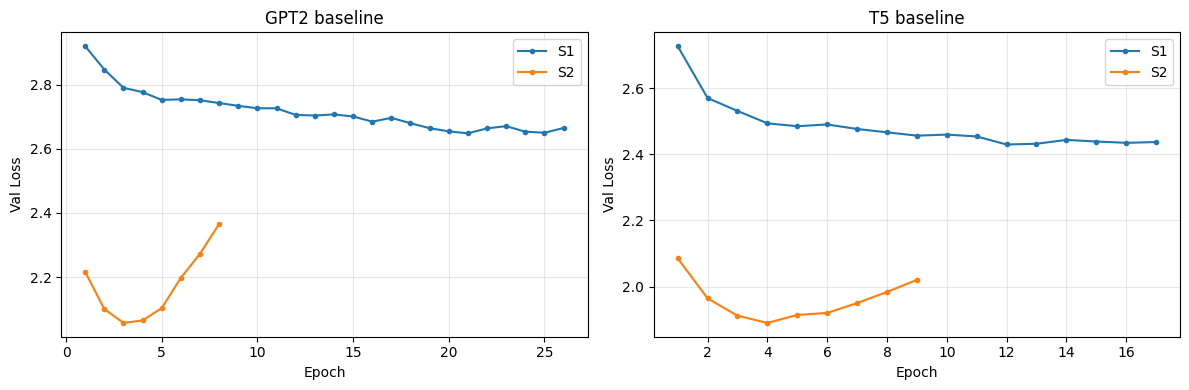

In [8]:
# Baseline training curves (S1 + S2) for each model
baseline_training = [r for r in training_results if r["tag"] == r["model"]]
models_with_data = sorted(set(r["model"] for r in baseline_training))

if models_with_data:
    fig, axes = plt.subplots(1, len(models_with_data), figsize=(6 * len(models_with_data), 4), squeeze=False)
    for idx, model in enumerate(models_with_data):
        ax = axes[0][idx]
        for r in baseline_training:
            if r["model"] != model:
                continue
            epochs = [h["epoch"] for h in r["history"]]
            val_loss = [h["val_loss"] for h in r["history"]]
            ax.plot(epochs, val_loss, marker="o", markersize=3, label=f"S{r['stage']}")
        ax.set_title(f"{model.upper()} baseline")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Val Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No baseline training results found.")

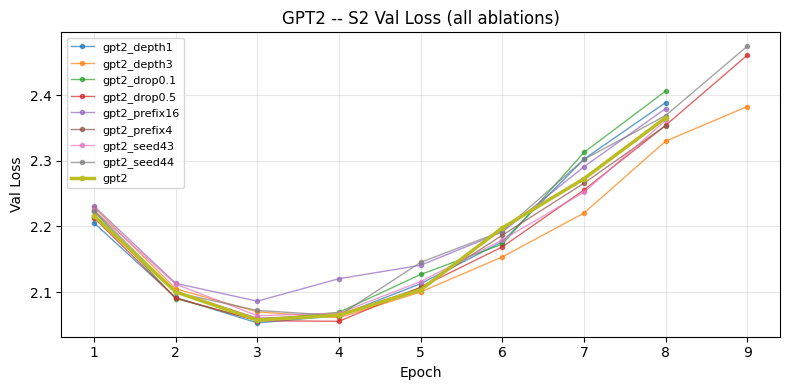

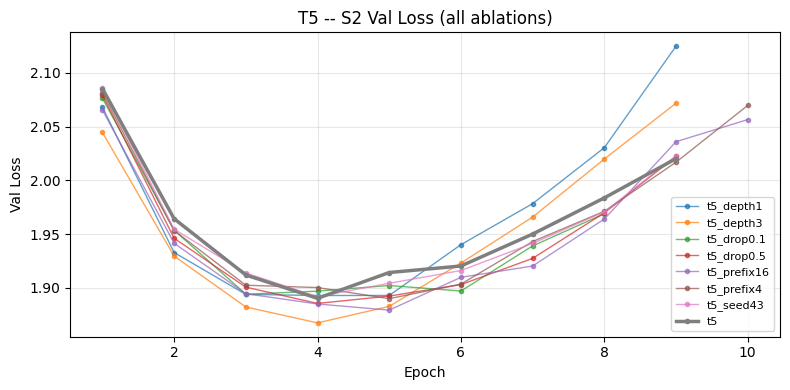

In [9]:
# S2 training curves for all ablation variants per model
s2_results = [r for r in training_results if r["stage"] == 2]
models_with_s2 = sorted(set(r["model"] for r in s2_results))

for model in models_with_s2:
    model_runs = [r for r in s2_results if r["model"] == model]
    fig, ax = plt.subplots(figsize=(8, 4))
    for r in model_runs:
        epochs = [h["epoch"] for h in r["history"]]
        val_loss = [h["val_loss"] for h in r["history"]]
        label = r["tag"]
        is_baseline = r["tag"] == r["model"]
        ax.plot(epochs, val_loss, marker="o", markersize=3, label=label,
                linewidth=2.5 if is_baseline else 1, alpha=1.0 if is_baseline else 0.7)
    ax.set_title(f"{model.upper()} -- S2 Val Loss (all ablations)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Sample Predictions (Best / Median / Worst by FENSE)

In [ ]:
import torch
from aac_metrics import evaluate as aac_evaluate


def score_predictions(predictions):
    """Score each prediction with sentence-level FENSE."""
    hyps = [p["hypothesis"].replace("\n", " ").strip() for p in predictions]
    refs = [[p["reference"].replace("\n", " ").strip()] for p in predictions]
    _, sents_scores = aac_evaluate(
        hyps, refs, metrics=["fense"],
        device="cuda" if torch.cuda.is_available() else "cpu",
    )
    fense_scores = sents_scores["fense"].tolist()
    scored = [{**p, "fense": s} for p, s in zip(predictions, fense_scores)]
    return sorted(scored, key=lambda x: x["fense"], reverse=True)


def show_predictions(scored, title, indices):
    """Display selected predictions."""
    print(f"\n--- {title} ---")
    for i in indices:
        if i >= len(scored):
            continue
        p = scored[i]
        print(f"  FENSE: {p['fense']:.4f}")
        print(f"  REF: {p['reference']}")
        print(f"  HYP: {p['hypothesis']}")
        print()

In [ ]:
for model in MODELS:
    path = RESULTS_DIR / model / "ablations" / "arch" / f"{model}_ablation_{model}.json"
    d = load_json(path)
    if d is None:
        continue
    scored = score_predictions(d["predictions"])
    n = len(scored)
    mid = n // 2

    print(f"\n{'='*60}")
    print(f"  {model.upper()} -- Sample Predictions ({n} total)")
    print(f"{'='*60}")

    show_predictions(scored, "BEST (top 3)", [0, 1, 2])
    show_predictions(scored, "MEDIAN", [mid - 1, mid, mid + 1])
    show_predictions(scored, "WORST (bottom 3)", [n - 3, n - 2, n - 1])

## 7. Failure Cases

In [ ]:
import re


def detect_failures(predictions):
    failures = []
    for p in predictions:
        hyp = p["hypothesis"].strip()
        reason = None

        if len(hyp) == 0:
            reason = "empty"
        elif len(hyp.split()) < 3:
            reason = "too short"
        else:
            words = hyp.lower().split()
            if len(set(words)) <= max(2, len(words) * 0.15):
                reason = "repetitive"
            elif re.search(r"(\b\w+\b)(?:\s+\1){4,}", hyp.lower()):
                reason = "word repetition"

        if reason:
            failures.append({**p, "failure": reason})
    return failures


for model in MODELS:
    for ablation_type in ["arch", "decoding"]:
        ablation_dir = RESULTS_DIR / model / "ablations" / ablation_type
        if not ablation_dir.exists():
            continue
        for f in sorted(ablation_dir.glob(f"{model}_ablation_*.json")):
            d = load_json(f)
            if d is None:
                continue
            tag = f.stem.replace(f"{model}_ablation_", "")
            failures = detect_failures(d["predictions"])
            if failures:
                print(f"{model}/{tag}: {len(failures)} failures out of {len(d['predictions'])}")
                for fail in failures[:3]:
                    print(f"  [{fail['failure']}]")
                    print(f"  REF: {fail['reference'][:100]}")
                    print(f"  HYP: {fail['hypothesis'][:100]}")
                    print()
                if len(failures) > 3:
                    print(f"  ... and {len(failures) - 3} more\n")

## 8. Full Summary (All Ablations, Sorted by FENSE)

In [ ]:
if len(eval_df) > 0:
    summary = eval_df.copy()
    summary["variant"] = summary["model"] + "/" + summary["tag"]
    available = [m for m in METRICS if m in summary.columns]
    summary = summary.set_index("variant")[available].round(4)
    summary = summary.sort_values("FENSE", ascending=False)
    styled = summary.style
    for col in available:
        styled = styled.background_gradient(cmap="Greys", subset=[col], vmin=summary[col].min() - 0.02)
    display(styled)